In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
california = fetch_california_housing(as_frame=True)

In [3]:
df = california.frame

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
X = df.drop("MedHouseVal", axis=1)

In [8]:
y = df["MedHouseVal"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print("Eğitim için ayrılan veri sayısı:", len(X_train))

Eğitim için ayrılan veri sayısı: 16512


In [11]:
print("Test için ayrılan veri sayısı:", len(X_test))

Test için ayrılan veri sayısı: 4128


In [12]:
model = DecisionTreeRegressor(max_depth=4, random_state=42)

In [13]:
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [14]:
y_pred = model.predict(X_test)

In [15]:
karsilastirma = pd.DataFrame({'Gerçek Fiyat': y_test[:5].values, 'Tahmin Edilen': y_pred[:5]})
karsilastirma

,Gerçek Fiyat,Tahmin Edilen
0,0.47700,1.376600
1,0.45800,1.362668
2,5.00001,2.893367
3,2.18600,2.354960
4,2.78000,1.699514


In [18]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Ortalama Mutlak Hata (MAE): {mae:.4f}")
print(f"R2 Skoru (Başarı oranı): {r2:.4f}")

Ortalama Mutlak Hata (MAE): 0.5587
R2 Skoru (Başarı oranı): 0.5540


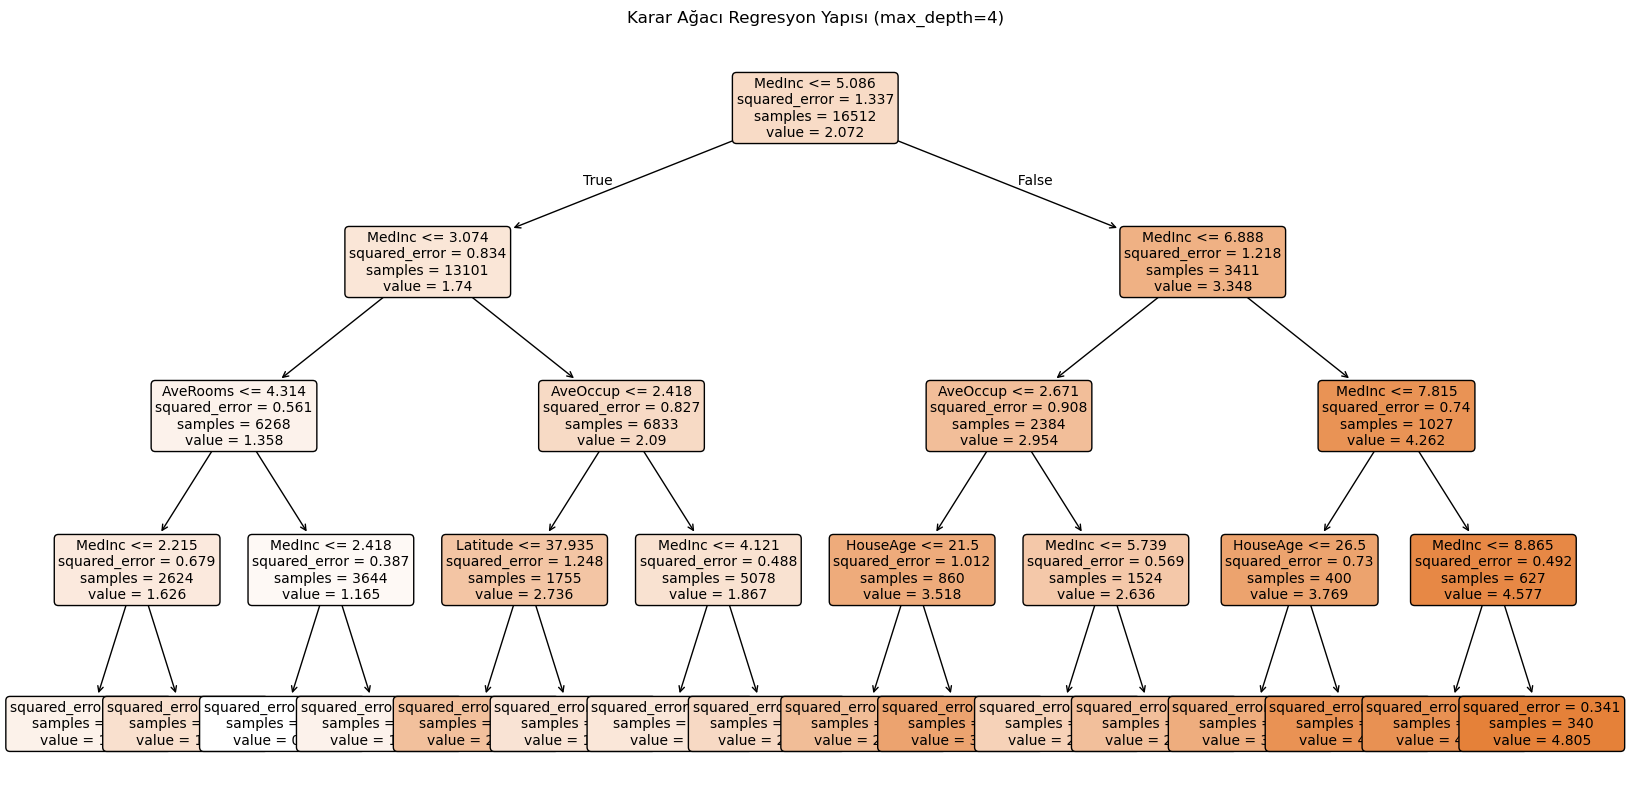

In [19]:
plt.figure(figsize=(20, 10))

plot_tree(model, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Karar Ağacı Regresyon Yapısı (max_depth=4)")
plt.show()

In [20]:
feature_importances = model.feature_importances_

In [24]:
importance_df = pd.DataFrame({
    'Ozellik': X.columns,
    'Onem_Skoru': feature_importances
})

In [25]:
importance_df = importance_df.sort_values(by='Onem_Skoru', ascending=False)

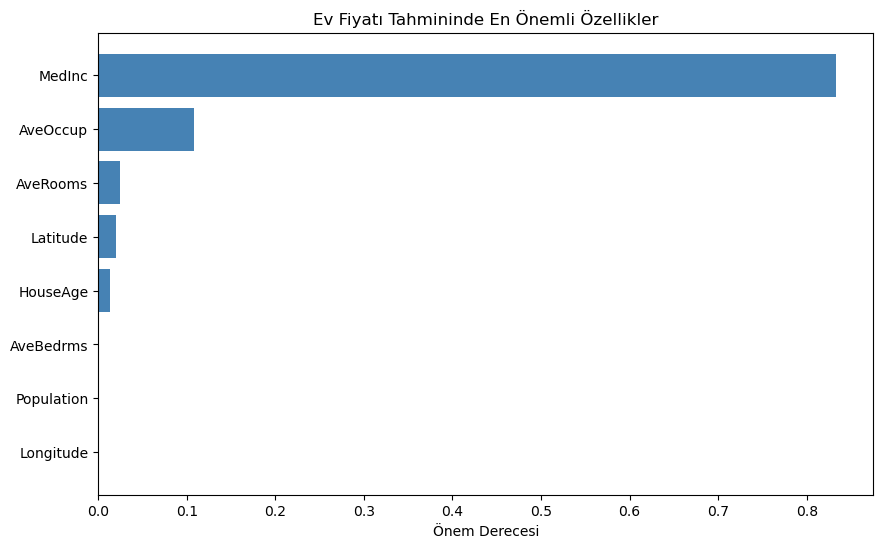

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Ozellik'], importance_df['Onem_Skoru'], color='steelblue')
plt.gca().invert_yaxis()  # En önemli özellik grafikte en üstte görünsün diye y eksenini ters çeviriyoruz
plt.xlabel('Önem Derecesi')
plt.title('Ev Fiyatı Tahmininde En Önemli Özellikler')
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
param_grid = {'max_depth': [2, 3, 4, 5, 6, 7, 8]}

In [29]:
base_model = DecisionTreeRegressor(random_state=42)

In [30]:
grid_search = GridSearchCV(
    estimator=base_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

In [31]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8]},
             scoring='neg_mean_squared_error')

In [32]:
print(f"Bulunan en ideal ağaç derinliği (max_depth): {grid_search.best_params_['max_depth']}")


Bulunan en ideal ağaç derinliği (max_depth): 8


In [33]:
model = grid_search.best_estimator_